In [1]:
!pip install -q tensorflow scikit-learn matplotlib

In [2]:
import os
import kagglehub
import sys
import pickle
import warnings
import numpy as np
import tensorflow as tf
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

2026-05-01 05:52:38.258983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777614758.468745      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777614758.539306      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777614759.049767      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777614759.049804      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777614759.049806      57 computation_placer.cc:177] computation placer alr

In [3]:
utils_path = kagglehub.dataset_download("shafayatulislam/ai-audio-monitor-utils")
print(utils_path)

/kaggle/input/datasets/shafayatulislam/ai-audio-monitor-utils


In [4]:
sys.path.insert(0, "/kaggle/input/datasets/shafayatulislam/ai-audio-monitor-utils")

In [5]:
from audio_utils import (
    TARGET_SR,
    N_FEATURES,
    MAX_LEN
)

In [6]:
print("TF version:", tf.__version__)
print(f"TARGET_SR = {TARGET_SR} Hz")
print(f"Nyquist ceiling = {TARGET_SR // 2} Hz")
print(f"N_FEATURES: {N_FEATURES}")
print(f"MAX_LEN: {MAX_LEN}")

TF version: 2.19.0
TARGET_SR = 16000 Hz
Nyquist ceiling = 8000 Hz
N_FEATURES: 60
MAX_LEN: 32


## Load EDA

In [7]:
temp_path = kagglehub.dataset_download("shafayatulislam/ai-audio-monitor-pickle")

In [8]:
for current_dir, dirs, files in os.walk(temp_path):
    if "eda.pkl" in files:
        eda_path = os.path.join(current_dir, "eda.pkl")

In [9]:
print("Path to the file:", eda_path)

Path to the file: /kaggle/input/datasets/shafayatulislam/ai-audio-monitor-pickle/eda.pkl


In [10]:
with open(eda_path, "rb") as f:
    eda = pickle.load(f)

In [11]:
X_raw = np.array([item[0] for item in eda])   
y_raw = np.array([item[1] for item in eda]) 

In [12]:
print(f"Loaded: {len(eda)} samples")
print(f"Feature shape: {X_raw[0].shape}")
print(f"Distribution: {Counter(y_raw.tolist())}")

Loaded: 8214 samples
Feature shape: (60, 32)
Distribution: Counter({0: 3000, 2: 3000, 1: 2214})


## Augmented Oversampling

In [13]:
TARGET_PER_CLASS = 2500

In [14]:
def augment_mfcc(mfcc: np.ndarray) -> np.ndarray:
    aug = mfcc.copy()

    shift = np.random.randint(-5, 6)
    aug   = np.roll(aug, shift, axis=1)
    if shift > 0:
        aug[:, :shift] = 0
    elif shift < 0:
        aug[:, shift:] = 0

    f0 = np.random.randint(0, N_FEATURES - 8)
    fw = np.random.randint(2, 9)
    aug[f0 : f0 + fw, :] = 0

    aug += np.random.normal(0, 0.03, aug.shape).astype(np.float32)

    return aug.astype(np.float32)

In [15]:
def balance_dataset(X, y, target=TARGET_PER_CLASS):
    balanced_X, balanced_y = [], []

    for cls in np.unique(y):
        idx     = np.where(y == cls)[0]
        class_X = X[idx]

        balanced_X.append(class_X)
        balanced_y.extend([cls] * len(idx))

        shortage = target - len(idx)
        if shortage > 0:
            aug_X = np.array([
                augment_mfcc(class_X[np.random.randint(len(class_X))])
                for _ in range(shortage)
            ])
            balanced_X.append(aug_X)
            balanced_y.extend([cls] * shortage)
            print(f"  Class {cls}: {len(idx):>5} - {len(idx)+shortage} (+{shortage} augmented)")
        else:
            print(f"  Class {cls}: {len(idx):>5}  (no oversampling needed)")

    return np.concatenate(balanced_X, axis=0), np.array(balanced_y)

In [16]:
X_bal, y_bal = balance_dataset(X_raw, y_raw)

  Class 0:  3000  (no oversampling needed)
  Class 1:  2214 - 2500 (+286 augmented)
  Class 2:  3000  (no oversampling needed)


In [17]:
print(f"Balanced distribution: {Counter(y_bal.tolist())}")
print(f"Total samples: {len(X_bal)}")

Balanced distribution: Counter({0: 3000, 2: 3000, 1: 2500})
Total samples: 8500


## Stratified train-val split

In [18]:
X_bal = X_bal[..., np.newaxis]

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    stratify=y_bal,
    random_state=42
)

In [20]:
print(f"Train: {X_train.shape}   dist: {Counter(y_train.tolist())}")
print(f"Val: {X_val.shape}    dist: {Counter(y_val.tolist())}")

Train: (6800, 60, 32, 1)   dist: Counter({2: 2400, 0: 2400, 1: 2000})
Val: (1700, 60, 32, 1)    dist: Counter({0: 600, 2: 600, 1: 500})


## Architecture

In [21]:
def build_model(input_shape=(N_FEATURES, MAX_LEN, 1), num_classes=3):
    inputs = tf.keras.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Conv2D(32, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Conv2D(128, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.40)(x)

    # Head
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.40)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs)

In [22]:
model = build_model()

I0000 00:00:1777614787.283761      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777614787.289644      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 60, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 60, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 60, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 30, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 30, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 8, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 15, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 15, 8, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 15, 8, 128)     │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 305,123 (1.16 MB)

 Trainable params: 304,227 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

## Compile & Train

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=15, restore_best_weights=True, verbose=1
    ),
]

In [26]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
)

Epoch 1/80


I0000 00:00:1777614793.053970     137 service.cc:152] XLA service 0x7ab39001c100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777614793.054004     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777614793.054008     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777614793.883263     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/107 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5087 - loss: 0.9181

I0000 00:00:1777614801.078353     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.6508 - loss: 0.6002 - val_accuracy: 0.6465 - val_loss: 0.7950 - learning_rate: 0.0010
Epoch 2/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7216 - loss: 0.4853 - val_accuracy: 0.5924 - val_loss: 0.8666 - learning_rate: 0.0010
Epoch 3/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7316 - loss: 0.4704 - val_accuracy: 0.7271 - val_loss: 0.4804 - learning_rate: 0.0010
Epoch 4/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7447 - loss: 0.4577 - val_accuracy: 0.7388 - val_loss: 0.4819 - learning_rate: 0.0010
Epoch 5/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7526 - loss: 0.4571 - val_accuracy: 0.6788 - val_loss: 0.5314 - learning_rate: 0.0010
Epoch 6/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7538 - loss: 0.4507 - val_accuracy: 0.7100 - val_loss: 0.4780 - learning_rate: 0.0010
Epoch 7/80
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7721 - loss: 0.4308 - val

## Training Curves

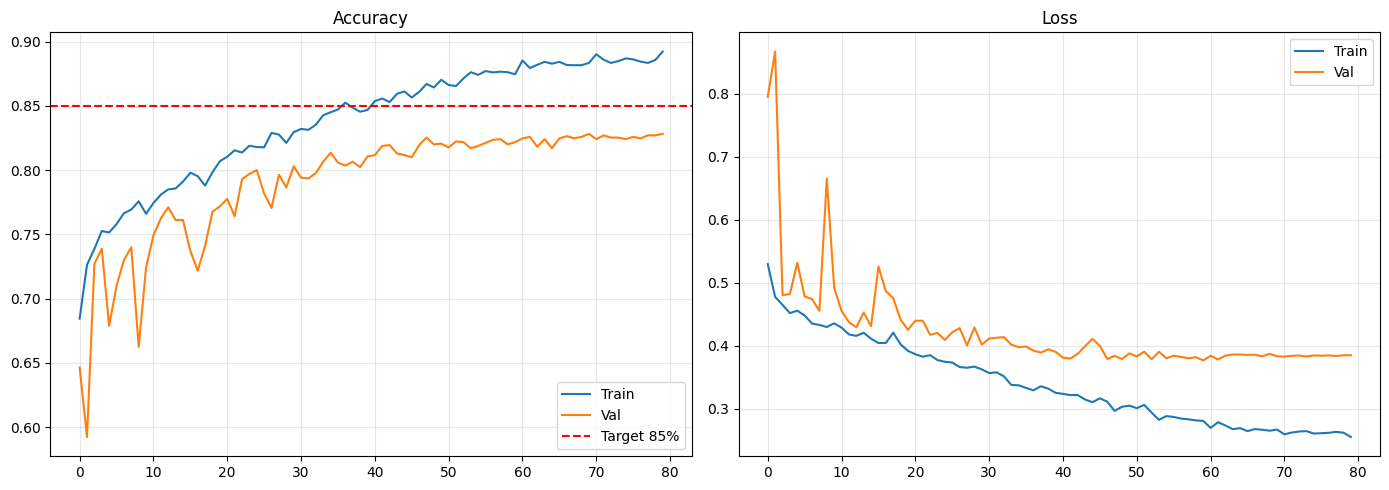

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].axhline(0.85, color="red", linestyle="--", label="Target 85%")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [28]:
best = max(history.history["val_accuracy"])
print(f"Best val accuracy: {best:.4f} ({best*100:.2f}%)")

Best val accuracy: 0.8282 (82.82%)


## Evaluation

Val Loss: 0.3832
Val Accuracy: 0.8282 (82.82%)
              precision    recall  f1-score   support

  Normal (0)       0.78      0.71      0.74       600
   Cough (1)       1.00      1.00      1.00       500
Abnormal (2)       0.73      0.80      0.77       600

    accuracy                           0.83      1700
   macro avg       0.84      0.84      0.84      1700
weighted avg       0.83      0.83      0.83      1700



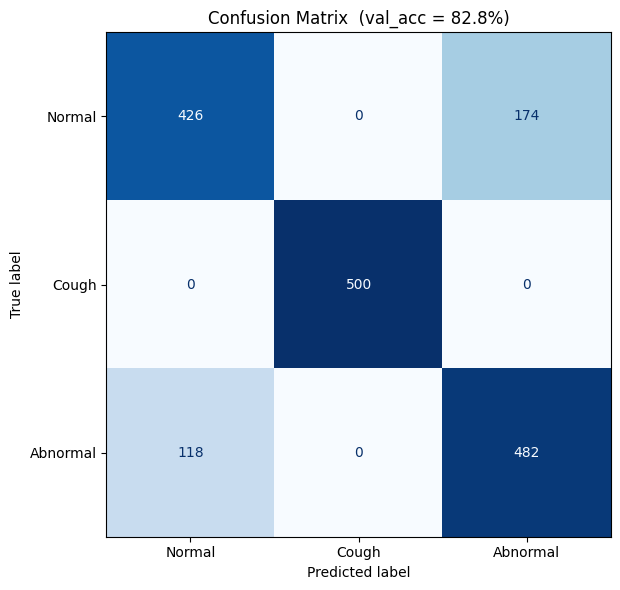

In [29]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Val Loss: {val_loss:.4f}")
print(f"Val Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
print(classification_report(y_val, y_pred, target_names=["Normal (0)", "Cough (1)", "Abnormal (2)"]))

cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=["Normal","Cough","Abnormal"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix  (val_acc = {val_acc*100:.1f}%)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## Save

In [30]:
model.save("audio_monitor.keras")

## Convert to TFLite

In [31]:
def representative_dataset():
    for i in range(min(300, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

In [32]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

In [33]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpqs0yiphy/assets


INFO:tensorflow:Assets written to: /tmp/tmpqs0yiphy/assets


Saved artifact at '/tmp/tmpqs0yiphy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134915671139408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671141520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671143248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671141328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671141136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671144208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671143632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671142864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671145168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671145360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134915671138832:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1777614937.734397      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777614937.734431      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777614937.756883      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


In [34]:
with open("model.tflite", "wb") as f:
    f.write(tflite_model)

In [35]:
print(f"Saved ({len(tflite_model)/1024:.1f} KB)")

Saved (319.0 KB)


## Verify Model

In [36]:
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()
inp_d = interpreter.get_input_details()
out_d = interpreter.get_output_details()

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [37]:
print(f"Input shape: {inp_d[0]['shape']}")
print(f"Output shape: {out_d[0]['shape']}")

Input shape: [ 1 60 32  1]
Output shape: [1 3]


In [38]:
preds = []
for i in range(len(X_val)):
    interpreter.set_tensor(inp_d[0]["index"], X_val[i:i+1])
    interpreter.invoke()
    preds.append(np.argmax(interpreter.get_tensor(out_d[0]["index"])))

In [39]:
preds = np.array(preds)
acc = np.mean(preds == y_val)

In [40]:
print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")

Accuracy : 0.8106 (81.06%)


In [41]:
print(classification_report(y_val, preds, target_names=["Normal (0)", "Cough (1)", "Abnormal (2)"]))

              precision    recall  f1-score   support

  Normal (0)       0.77      0.68      0.73       600
   Cough (1)       0.94      1.00      0.97       500
Abnormal (2)       0.73      0.78      0.76       600

    accuracy                           0.81      1700
   macro avg       0.82      0.82      0.82      1700
weighted avg       0.81      0.81      0.81      1700

